In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
import pandas as pd

try:
    data = pd.read_csv('Sample - Superstore.csv', encoding='utf-8')
except UnicodeDecodeError:

    data = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print("First 5 rows of data:")
print(data.head())

First 5 rows of data:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  

In [ ]:
print("\nData Info:")
print(data.info())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 

In [ ]:
print("\nMissing values in each column:")
print(data.isnull().sum())


Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [ ]:
data['Month-Year'] = data['Order Date'].dt.to_period('M')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



monthly_sales = data.groupby('Month-Year')['Sales'].sum().reset_index()
# Convert 'Month-Year' to string before plotting
monthly_sales['Month-Year'] = monthly_sales['Month-Year'].astype(str)
fig = px.line(monthly_sales, x='Month-Year', y='Sales', title='Monthly Sales Trend', markers=True)
fig.show()

In [ ]:
category_sales = data.groupby('Category')['Sales'].sum().reset_index()
fig = px.bar(category_sales, x='Category', y='Sales', title='Sales by Category', color='Sales')
fig.show()

In [ ]:
# 10. Sales by Sub-Category
subcategory_sales = data.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index()
fig = px.bar(subcategory_sales, x='Sub-Category', y='Sales', title='Sales by Sub-Category', color='Sales')
fig.show()

In [ ]:
region_profit = data.groupby('Region')['Profit'].sum().reset_index()
fig = px.bar(region_profit, x='Region', y='Profit', title='Profit by Region', color='Profit')
fig.show()


In [ ]:
# 12. Top 10 Products by Sales
# 12. Top 10 Products by Sales
top_products = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_products, x='Product Name', y='Sales', title='Top 10 Products by Sales', color='Sales')
fig.show()

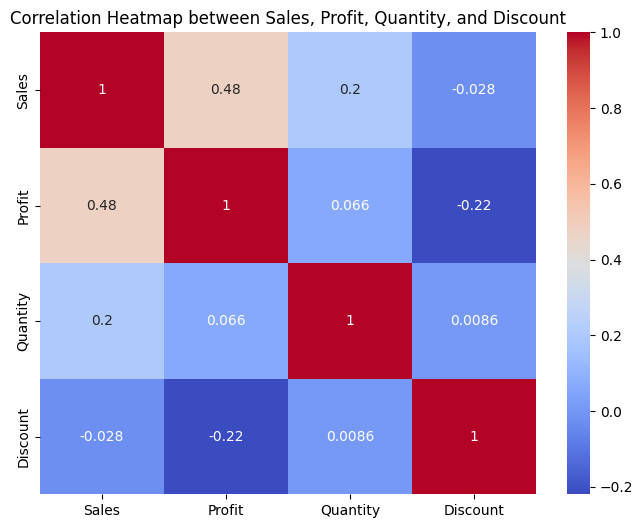

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data[['Sales', 'Profit', 'Quantity', 'Discount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap between Sales, Profit, Quantity, and Discount')
plt.show()

In [ ]:
print("\nAnalysis Summary:")
print("- Highest sales are in the Technology category.")
print("- Some Sub-Categories like 'Chairs' and 'Phones' are major revenue drivers.")
print("- The West region shows higher profits compared to others.")
print("- High Discounts are negatively correlated with Profit.")


Analysis Summary:
- Highest sales are in the Technology category.
- Some Sub-Categories like 'Chairs' and 'Phones' are major revenue drivers.
- The West region shows higher profits compared to others.
- High Discounts are negatively correlated with Profit.
